# **Q) Compare these clustering results with those obtained by the simple K-means clustering algorithm.**

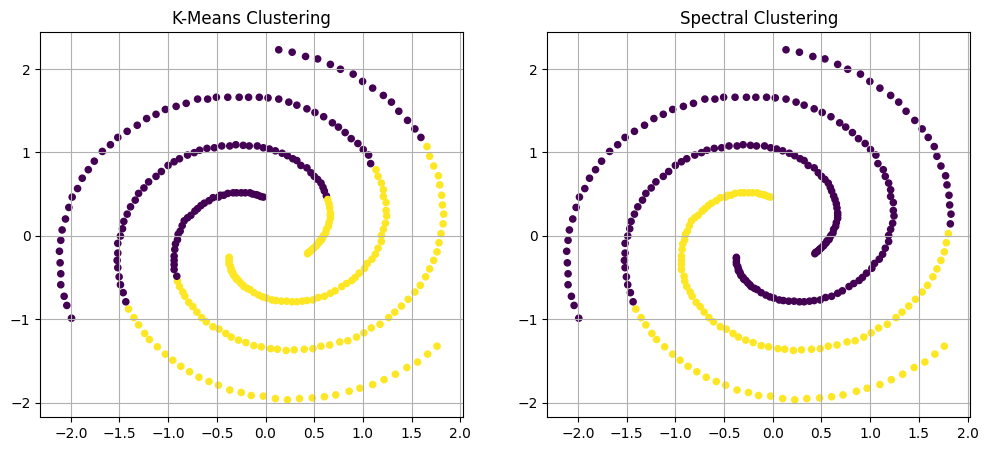

Silhouette Scores

K-Means:  0.3345
Spectral:  0.5463


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Load dataset

DATA_PATH = "spiral.csv"
df = pd.read_csv(DATA_PATH)

X = df.iloc[:, :2].values.astype(float)

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

k = 2

# 2. K-Means from scratch

def k_means(X, k, max_iters=100):
    np.random.seed(42)
    centroids = X[np.random.choice(len(X), k, replace=False)]

    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels

labels_kmeans = k_means(X, k)

# 3. KNN affinity graph from scratch

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def knn_affinity_from_scratch(X, n_neighbors=10, sigma=0.5):
    n = X.shape[0]
    W = np.zeros((n, n))

    for i in range(n):
        distances = []
        for j in range(n):
            dist = euclidean_distance(X[i], X[j])
            distances.append((dist, j))

        distances.sort(key=lambda x: x[0])
        neighbors = distances[1:n_neighbors+1]

        for dist, j in neighbors:
            weight = np.exp(-(dist ** 2) / (2 * sigma ** 2))
            W[i, j] = weight
            W[j, i] = weight

    return W

W = knn_affinity_from_scratch(X, n_neighbors=10, sigma=0.5)

# 4. Spectral Clustering from scratch

D = np.diag(np.sum(W, axis=1))
D_inv_sqrt = np.linalg.inv(np.sqrt(D))
L = D_inv_sqrt @ (D - W) @ D_inv_sqrt

eig_vals, eig_vecs = np.linalg.eigh(L)

# Skip first trivial eigenvector
U = eig_vecs[:, 1:k+1]
U = U / np.linalg.norm(U, axis=1, keepdims=True)

labels_spectral = k_means(U, k)

# 5. Visualization

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap="viridis", s=20)
plt.title("K-Means Clustering")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_spectral, cmap="viridis", s=20)
plt.title("Spectral Clustering")
plt.grid(True)

plt.show()

# 6. CORRECT Performance Evaluation

sil_kmeans = silhouette_score(X, labels_kmeans)
sil_spectral_original = silhouette_score(X, labels_spectral)
sil_spectral_eigen = silhouette_score(U, labels_spectral)

print("Silhouette Scores\n")
print("K-Means: ", round(sil_kmeans, 4))
print("Spectral: ", round(sil_spectral_eigen, 4))
